In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# data loading
# Fetch the dataset directly from the Our World in Data catalog URL
url = "https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv"
df = pd.read_csv(url)

# Convert date column to datetime type for proper time-series plotting
df['date'] = pd.to_datetime(df['date'])

In [3]:
# Filter out regional/global aggregates to isolate individual countries
df_countries = df[~df['code'].str.startswith('OWID_', na=False)]

# Identify the highest total confirmed cases per country to find the top performing metrics
# We use max() because 'total_cases' and 'total_deaths' are cumulative metrics
country_totals = (
    df_countries.groupby('country')[['total_cases', 'total_deaths']]
    .max()
    .reset_index()
)

# Extract top country lists based on total confirmed cases
top_10_cases = country_totals.nlargest(10, 'total_cases')
top_3_cases_list = top_10_cases.head(3)['country'].tolist()

# Extract top country lists based on total deaths
top_10_deaths = country_totals.nlargest(10, 'total_deaths')

# Filter time-series data for the trend lines
df_top3 = df_countries[df_countries['country'].isin(top_3_cases_list)]

# Set aesthetics for Matplotlib & Seaborn
sns.set_theme(style="whitegrid")

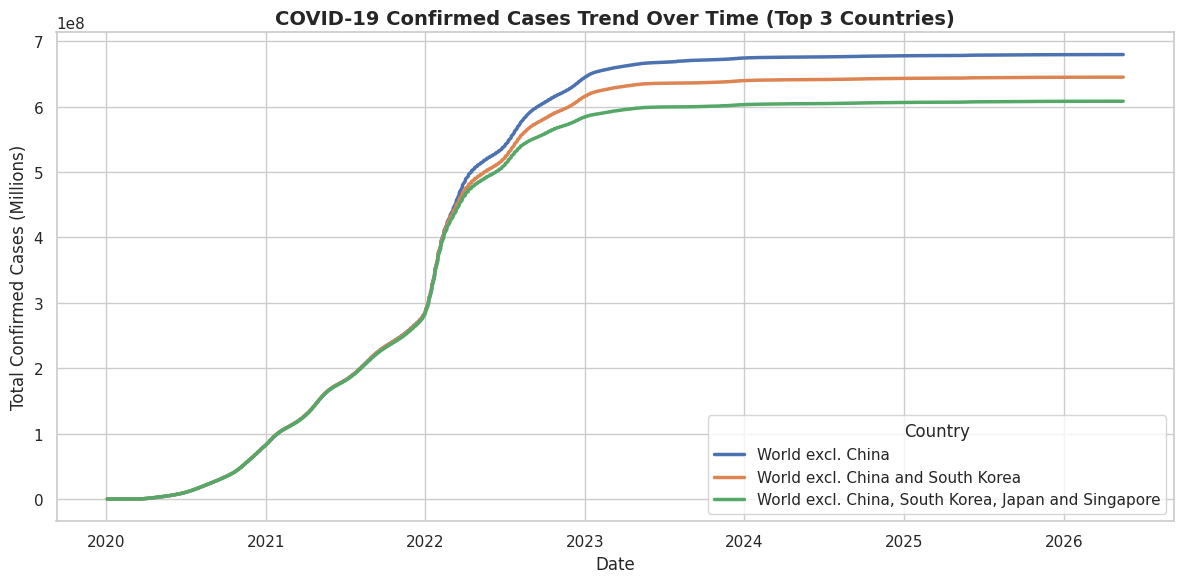

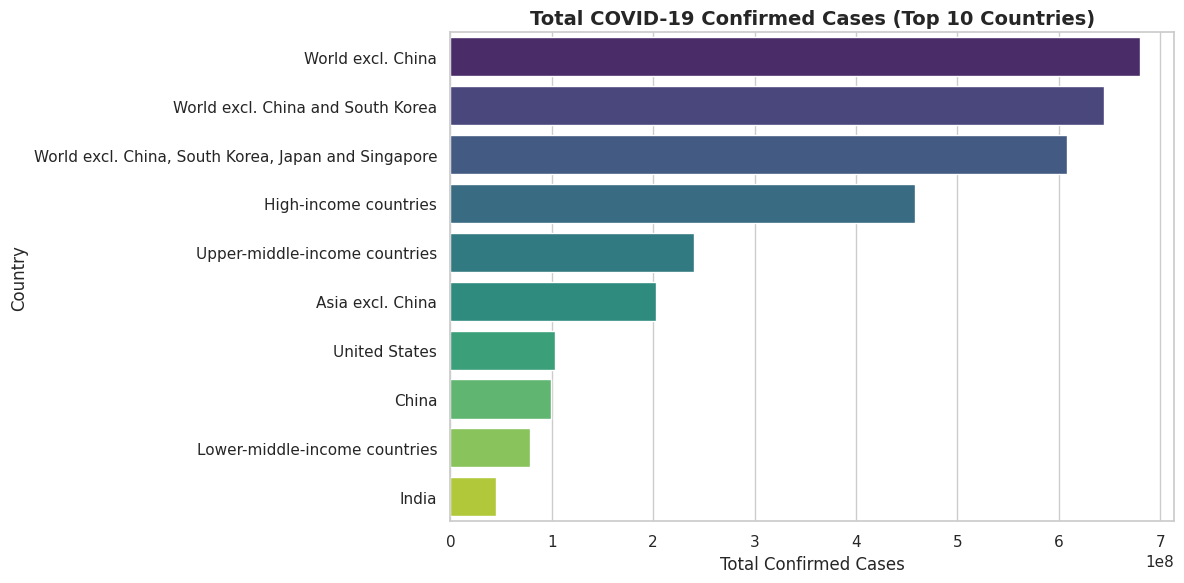

In [4]:

#  Plot the trend of confirmed cases over time for the top 3 countries
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_top3, x='date', y='total_cases', hue='country', linewidth=2.5)
plt.title('COVID-19 Confirmed Cases Trend Over Time (Top 3 Countries)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Confirmed Cases (Millions)', fontsize=12)
plt.legend(title='Country')
plt.tight_layout()
plt.show()

#  Create a bar chart showing the total number of confirmed cases for the top 10 countries
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_cases, x='total_cases', y='country', palette='viridis', hue='country', legend=False)
plt.title('Total COVID-19 Confirmed Cases (Top 10 Countries)', fontsize=14, fontweight='bold')
plt.xlabel('Total Confirmed Cases', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()





In [5]:
#  Create an interactive line chart showing the trend of confirmed cases over time for the top 3 countries
fig_line = px.line(
    df_top3, 
    x='date', 
    y='total_cases', 
    color='country',
    title='Interactive COVID-19 Confirmed Cases Trend (Top 3 Countries)',
    labels={'date': 'Date', 'total_cases': 'Total Confirmed Cases', 'country': 'Country'}
)
fig_line.update_layout(hovermode='x unified', template='plotly_white')
fig_line.show()


In [6]:
#  Create an interactive bar chart to show the total number of deaths for the top 10 countries
fig_bar = px.bar(
    top_10_deaths, 
    x='total_deaths', 
    y='country', 
    orientation='h',
    color='total_deaths',
    color_continuous_scale='Reds',
    title='Top 10 Countries by Total COVID-19 Deaths',
    labels={'total_deaths': 'Total Deaths', 'country': 'Country'}
)
fig_bar.update_layout(yaxis={'categoryorder': 'total ascending'}, template='plotly_white')
fig_bar.show()